In [255]:
from spar import basicFunction, readBasicFunctions, kineticMapping, potentialMapping
import importlib

importlib.reload(spar)
import numpy as np
import re
import matplotlib.pyplot as plt
%matplotlib inline

### KEO Demo
Below we illustrate how SPAR is used to return the $G$ matrix and pseudopotential $U$ of an A2BC type molecule at a single point such that it might be evaluated using multi-dimensional quadrature. 

We highlight how the same checkpoint file and basic functions are usable for both H2CS and H2CO, merely by changing the masses and as such is valid for all molecules of the same structure. 

In [73]:
toRadians = np.pi/180.0

# Case of H2CS
masses = np.array([12.00000000, 31.9720707, 1.00782503223, 1.00782503223])
# Geometry we wish to evaluate KEO at for quadrature (single-point calculation)
internalCoordinates = np.array([1.608952, 1.086848, 1.086848, 121.750*toRadians, 121.750*toRadians, np.pi])

# Read basic functions for A2BC type molecule
basicFunctions = readBasicFunctions("KEO/A2BC/combination.chk")

# Read KEO checkpoint
keoMapping = kineticMapping("KEO/A2BC/kinetic.chk")
# Evaluate returns specified component component
keoMapping.evaluate("gvib", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("grot", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("gcor", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("pseudo", basicFunctions, internalCoordinates, masses)

# To switch to H2CO all we need is to change masses
masses = np.array([12.00000000, 15.99491463, 1.00782503223, 1.00782503223])
# Geometry we wish to evaluate KEO at for quadrature (single-point calculation)
internalCoordinates = np.array([1.203374200, 1.103774652, 1.103774652, 2.12658330381800, 2.12658330381800, np.pi])
keoMapping.evaluate("gvib", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("grot", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("gcor", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("pseudo", basicFunctions, internalCoordinates, masses) 

np.float64(-16.12726266663172)

In [179]:
# HCO+ potential from Winterhoff et al 2018
internalCoordinates = [2.017, 2.393, 0]

basicFunctions = readBasicFunctions("Potentials/HCO+/combination.chk")
basicFunctions[1][2].evaluate(internalCoordinates[0])

np.float64(0.7113145534701458)

In [159]:
pesMapping.potentialBasicFunctionIndices

array([[0, 0, 1],
       [0, 0, 2],
       [0, 0, 3],
       [1, 0, 1],
       [0, 1, 1],
       [0, 1, 2],
       [0, 1, 3],
       [2, 0, 0],
       [0, 2, 0],
       [2, 0, 1],
       [2, 0, 2],
       [1, 1, 0],
       [1, 1, 1],
       [3, 0, 0],
       [0, 3, 0],
       [3, 0, 1],
       [1, 2, 0]])

In [166]:
basicFunctions[1][2].evaluate(2)

np.float64(0.00035486401745902694)

In [186]:
# HCO+ potential from Winterhoff et al 2018
internalCoordinates = np.array([2.017, 2.393, 0])
pesMapping = potentialMapping("Potentials/HCO+/potential.chk")
pesMapping.evaluate(basicFunctions, internalCoordinates)

np.float64(-198623607.7353921)

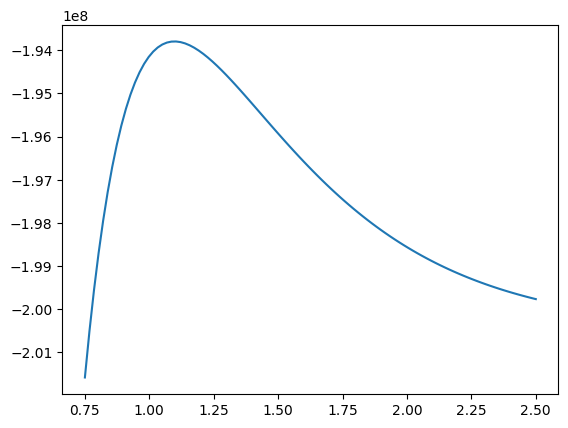

In [187]:
rGrid = np.linspace(0.75, 2.5, 100)
potentialOnGrid = np.zeros(len(rGrid))
for i in range(len(rGrid)):
    internalCoordinates[0] = rGrid[i]
    potentialOnGrid[i] = pesMapping.evaluate(basicFunctions, internalCoordinates)

plt.plot(rGrid, potentialOnGrid)

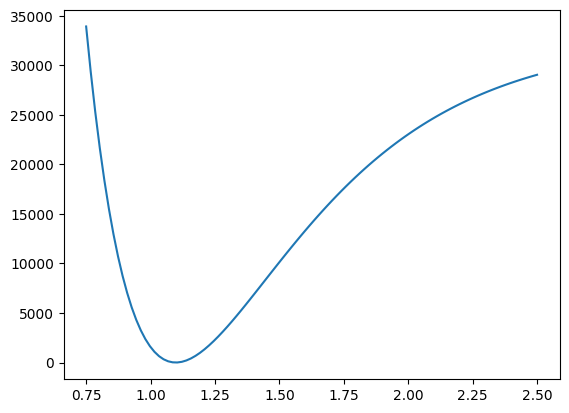

In [188]:
potentialOnGrid = pesMapping.potentialCoefficients[7]*basicFunctions[1][2].evaluate(rGrid)

plt.plot(rGrid, potentialOnGrid)

In [256]:
# AMES potential for CS2 Huang et al 2024
internalCoordinates = np.array([1.5521, 1.5521, np.pi])

basicFunctions = readBasicFunctions("Potentials/CS2/combination.chk")

In [223]:
basicFunctions[1][1].evaluate(1.5521 + 0.1)

np.float64(0.9979820388269588)

In [257]:
basicFunctions[3]

{0: <spar.basicFunction at 0x75e4d0866590>,
 1: <spar.basicFunction at 0x75e4d0866530>,
 2: <spar.basicFunction at 0x75e4d08664a0>,
 3: <spar.basicFunction at 0x75e4d0866440>,
 4: <spar.basicFunction at 0x75e4d08663e0>,
 5: <spar.basicFunction at 0x75e4d0866380>,
 6: <spar.basicFunction at 0x75e4d0866320>,
 7: <spar.basicFunction at 0x75e4d08662c0>,
 8: <spar.basicFunction at 0x75e4d0866260>,
 9: <spar.basicFunction at 0x75e4d0866200>,
 10: <spar.basicFunction at 0x75e4d08661a0>,
 11: <spar.basicFunction at 0x75e4d0866140>,
 12: <spar.basicFunction at 0x75e4d08660e0>,
 13: <spar.basicFunction at 0x75e4d0866080>,
 14: <spar.basicFunction at 0x75e4d0866560>}